# 01 — Tide Layer: Macro Bias & Risk Budget

**Strategy reference:** §7 (Tide Layer), §15 (Risk Budgeting).

Tide is the **macro layer**.  It does *not* trigger trades — it
computes (bias, risk multiplier, vol regime, ES budget) that
throttle Wave and Ripple.  Cadence: ~60 s event-time.

Key formulas we'll explore on real BTC data:

* **§7.4.1 — Realized volatility**  
  $\hat{\sigma}_{\text{realized}} = \sqrt{\tfrac{1}{N}\sum r_i^2}\cdot\sqrt{T/\Delta t}$
* **§7.4.2 — Directional efficiency**  
  $\eta = |\sum \Delta P_i| / \sum|\Delta P_i|$
* **§7.4.3 — Liquidity Stress Index**
* **§7.4.4 — Expected Shortfall** (parametric)  
  $\text{ES}_\alpha \approx \sigma_{\text{port}}\,\phi(z_\alpha)/(1-\alpha)$
* **§7.4.7 — Risk multiplier** (deterministic function of vol regime + LSI)

In [7]:
# ── Data-source configuration ─────────────────────────────────────────
# OHLCV (Parquet) — S3 or local, controlled by DATA_STORE env var:
#   Local (default):  reads <project_root>/data/ohlcv/...
#   S3:               uncomment the two lines below
# import os
# os.environ["DATA_STORE"] = "s3"
# os.environ["S3_BUCKET"]  = "trading-data-centheos"
#
# Tick data (HDF5) — always stored locally; pull from S3 on demand:
#   load_ticks(...)              → use local cache (fast, no network)
#   load_ticks(..., refresh=True) → sync from S3 then read (ETag-gated)
#   Requires: AWS_PROFILE=trading (or AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY)
import os
os.environ["AWS_PROFILE"] = "trading"
os.environ["S3_BUCKET"]   = "trading-data-centheos"
# ─────────────────────────────────────────────────────────────────────

import sys, importlib
from pathlib import Path

_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    if (_cand / "schemas.py").exists():
        _root = _cand; break
else:
    raise RuntimeError("Could not locate project root (no schemas.py found)")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import notebooks.utils as _utils_mod
importlib.reload(_utils_mod)   # always pick up on-disk changes without restarting the kernel

from notebooks.utils import (
    load_ohlcv, list_ohlcv, load_ticks, latest_book,
    plot_ohlcv, plot_equity_curve, configure_pandas, env_summary,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

configure_pandas()
%matplotlib inline

In [8]:
from schemas import TideConfig, VolRegime, TideBias
from tide.tide_engine import TideEngine
from tide.tide_features import (
    TideFeatureParams, build_tide_feature_frame,
    rolling_realized_volatility, rolling_directional_efficiency,
)

## 1. Load a multi-month BTC slice
Tide horizons are hours–days so we want at least a few months of
1-minute bars.

In [9]:
exchange, symbol, timeframe = 'binance', 'BTCUSDT', '1m'
ohlcv = load_ohlcv(exchange, symbol, timeframe).tail(60_000).copy()
print(f'{len(ohlcv):,} bars  ({ohlcv.index.min()} → {ohlcv.index.max()})')

60,000 bars  (2026-04-09 17:59:00 → 2026-05-21 09:58:00)


## 2. Realized volatility (§7.4.1)
Annualized continuous-time vol from log returns:

$$\hat{\sigma} = \sqrt{\tfrac{1}{N}\sum r_i^2}\cdot \sqrt{T/\Delta t}$$

where `T` is the continuous-crypto-year (365·24·3600 s).

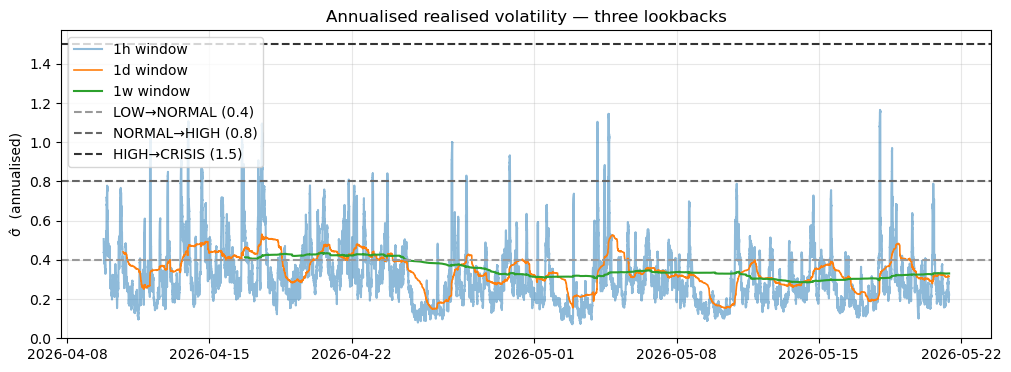

In [10]:
vol_1h  = rolling_realized_volatility(ohlcv['close'], window=60,    bar_seconds=60)
vol_1d  = rolling_realized_volatility(ohlcv['close'], window=1440,  bar_seconds=60)
vol_1w  = rolling_realized_volatility(ohlcv['close'], window=10080, bar_seconds=60)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vol_1h.index,  vol_1h,  label='1h window',  alpha=0.5)
ax.plot(vol_1d.index,  vol_1d,  label='1d window',  linewidth=1.2)
ax.plot(vol_1w.index,  vol_1w,  label='1w window',  linewidth=1.5)
ax.axhline(0.40, ls='--', color='#999', label='LOW→NORMAL (0.4)')
ax.axhline(0.80, ls='--', color='#666', label='NORMAL→HIGH (0.8)')
ax.axhline(1.50, ls='--', color='#333', label='HIGH→CRISIS (1.5)')
ax.set_title('Annualised realised volatility — three lookbacks')
ax.set_ylabel('σ̂  (annualised)'); ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.show()

## 3. Directional efficiency η (§7.4.2)
η ≈ 1 means trending, η ≈ 0 means choppy.  Tide & Wave both use it,
Tide on a slower window.

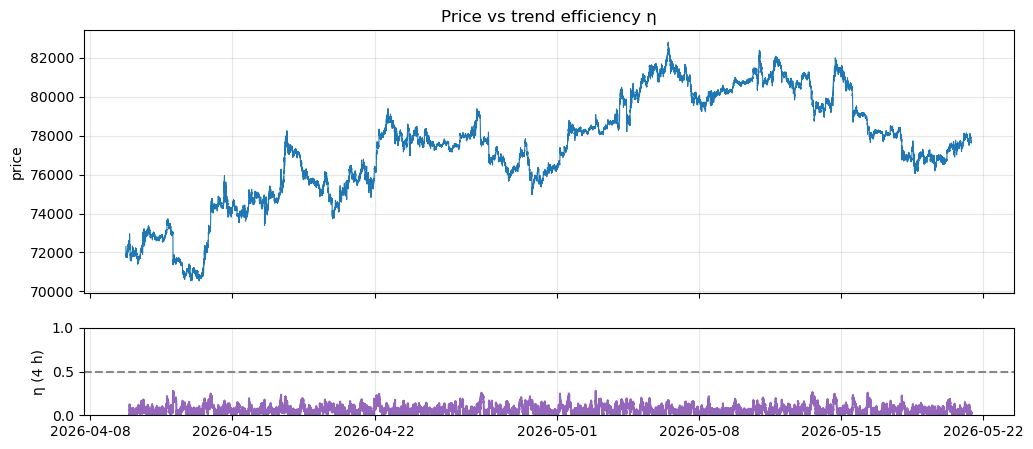

In [11]:
eta = rolling_directional_efficiency(ohlcv['close'], window=240)  # 4h
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(ohlcv.index, ohlcv['close'], color='#1f77b4', linewidth=0.8)
axes[0].set_ylabel('price'); axes[0].grid(alpha=0.3)
axes[1].plot(eta.index, eta, color='#9467bd')
axes[1].axhline(0.5, ls='--', color='#888')
axes[1].set_ylabel('η (4 h)'); axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)
axes[0].set_title('Price vs trend efficiency η')
plt.show()

## 4. End-to-end Tide feature frame
`build_tide_feature_frame` does everything: returns, realised vol,
η, LSI proxy, vol-regime label, and a bias signal.

In [12]:
params = TideFeatureParams(
    vol_window=60, eta_window=240, lsi_window=720, bar_seconds=60.0,
)
tide_features = build_tide_feature_frame(ohlcv, params)
tide_features.tail()

,open,high,low,close,volume,log_return,realized_vol,eta,net_move,vol_regime,bias,lsi
timestamp,,,,,,,,,,,,
2026-05-21 09:54:00,"77,629.200000","77,629.400000","77,613.600000","77,622.000000",63.568000,-0.000093,0.226117,0.030925,-142.900000,VolRegime.LOW,TideBias.NEUTRAL,-0.542257
2026-05-21 09:55:00,"77,622.000000","77,639.000000","77,608.000000","77,639.000000",79.086000,0.000219,0.225471,0.027146,-125.900000,VolRegime.LOW,TideBias.NEUTRAL,-0.240302
2026-05-21 09:56:00,"77,639.000000","77,664.500000","77,638.900000","77,657.000000",58.216000,0.000232,0.223964,0.022209,-103.300000,VolRegime.LOW,TideBias.NEUTRAL,-0.406745
2026-05-21 09:57:00,"77,657.000000","77,657.000000","77,646.300000","77,646.300000",27.281000,-0.000138,0.222830,0.021262,-98.800000,VolRegime.LOW,TideBias.NEUTRAL,-0.762504
2026-05-21 09:58:00,"77,646.300000","77,650.400000","77,646.300000","77,646.300000",31.208000,0.000000,0.222794,0.027965,-129.100000,VolRegime.LOW,TideBias.NEUTRAL,-0.850370


### 4.1 LSI components vs composite

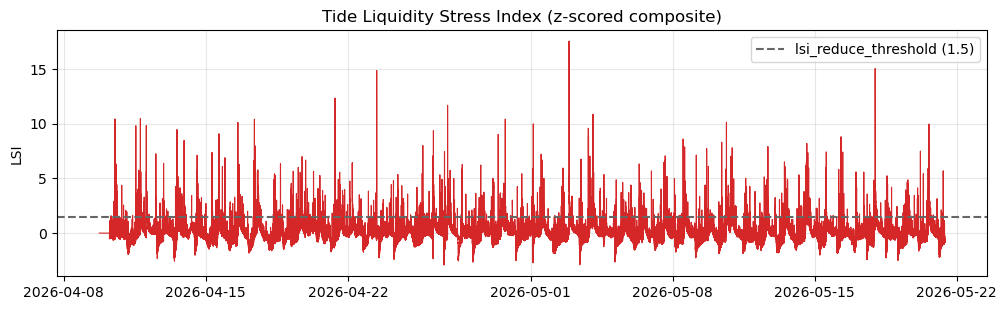

In [13]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(tide_features.index, tide_features['lsi'], color='#d62728', linewidth=0.8)
ax.axhline(1.5, ls='--', color='#666', label='lsi_reduce_threshold (1.5)')
ax.set_title('Tide Liquidity Stress Index (z-scored composite)')
ax.set_ylabel('LSI'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

### 4.2 Volatility regime timeline
The labels are taken straight from §27.1 thresholds
`[0.4, 0.8, 1.5]` for LOW / NORMAL / HIGH / CRISIS.

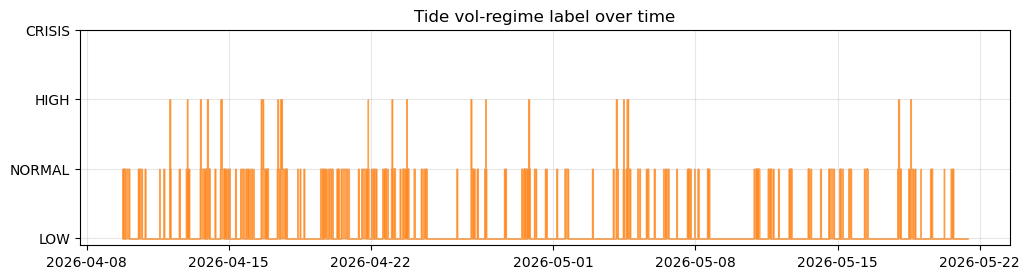

In [14]:
regime_to_int = {VolRegime.LOW: 0, VolRegime.NORMAL: 1,
                 VolRegime.HIGH: 2, VolRegime.CRISIS: 3}
reg_series = tide_features['vol_regime'].dropna().map(regime_to_int)
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.fill_between(reg_series.index, reg_series, step='pre',
                alpha=0.7, color='#ff7f0e')
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['LOW', 'NORMAL', 'HIGH', 'CRISIS'])
ax.set_title('Tide vol-regime label over time'); ax.grid(alpha=0.3)
plt.show()

## 5. Risk multiplier sensitivity (§7.4.7)
Pseudocode reminder:

```
base = config.risk_mult_by_regime[vol_regime]    # [1.0, 0.8, 0.5, 0.0]
if lsi > 1.5:
    base -= (lsi - 1.5) * 0.2
return clip(base, 0, 1)
```

We sweep both axes and produce the response surface.

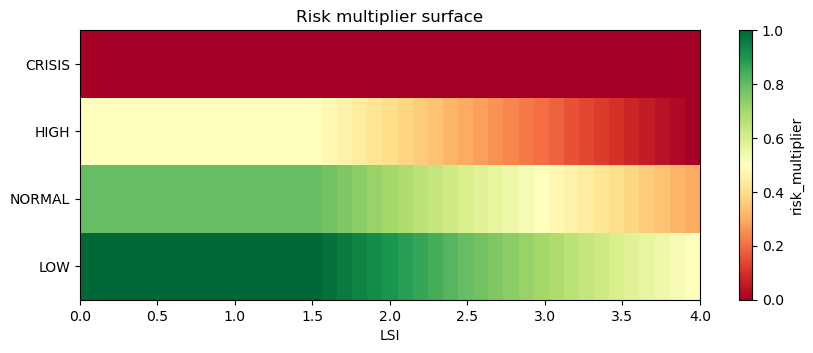

In [15]:
cfg = TideConfig()
engine = TideEngine(cfg)

regimes = [VolRegime.LOW, VolRegime.NORMAL, VolRegime.HIGH, VolRegime.CRISIS]
lsi_grid = np.linspace(0, 4, 41)
Z = np.zeros((len(regimes), lsi_grid.size))
for i, reg in enumerate(regimes):
    for j, lsi in enumerate(lsi_grid):
        engine.set_vol_regime(reg)
        engine.set_liquidity_stress(float(lsi))
        snap = engine.update(timestamp=(j + 1) * cfg.update_interval_ms + i * 10_000_000)
        Z[i, j] = snap.risk_multiplier

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(Z, aspect='auto', origin='lower',
               extent=[lsi_grid[0], lsi_grid[-1], -0.5, len(regimes) - 0.5],
               cmap='RdYlGn')
ax.set_yticks(range(len(regimes)))
ax.set_yticklabels([r.value for r in regimes])
ax.set_xlabel('LSI'); ax.set_title('Risk multiplier surface')
plt.colorbar(im, ax=ax, label='risk_multiplier')
plt.show()

## 6. Parametric Expected Shortfall (§7.4.4 / §15.2)
$$\text{ES}_\alpha \approx \sigma_{\text{port}} \cdot \frac{\phi(z_\alpha)}{1-\alpha}$$

Worked example: a 100 USDT notional, σ̂ = 80 % annualised, 1-day horizon.

In [16]:
# Hard-coded normal constants so the notebook does not depend on scipy.
# φ(z_{0.95}) / (1 - 0.95) ≈ 2.063  (see §6 confidence-level note)
Z_95 = 1.6448536269514722
PHI_Z95 = 0.10314211381526195
ES_MULT_95 = PHI_Z95 / 0.05  # ≈ 2.063

def parametric_es(notional, sigma_ann, horizon_years=1/365, mult=ES_MULT_95):
    return notional * sigma_ann * np.sqrt(horizon_years) * mult

examples = pd.DataFrame([
    {'notional': 100,    'sigma_ann': 0.80, 'horizon_d': 1},
    {'notional': 1_000,  'sigma_ann': 0.60, 'horizon_d': 1},
    {'notional': 1_000,  'sigma_ann': 1.20, 'horizon_d': 1},
    {'notional': 1_000,  'sigma_ann': 0.60, 'horizon_d': 7},
])
examples['ES_95'] = [
    parametric_es(r.notional, r.sigma_ann, r.horizon_d / 365)
    for r in examples.itertuples()
]
examples

,notional,sigma_ann,horizon_d,ES_95
0,100,0.800000,1,8.637928
1,1000,0.600000,1,64.784460
2,1000,1.200000,1,129.568920
3,1000,0.600000,7,171.403569


## 7. Drive `TideEngine` on real data
Replay our 1-min bars one at a time, feeding the *measured* vol
regime + LSI into the engine, and capture every snapshot.

In [17]:
engine = TideEngine(TideConfig(update_interval_ms=60_000))

snaps = []
for ts, row in tide_features.dropna().iterrows():
    engine.set_vol_regime(row['vol_regime'])
    engine.set_liquidity_stress(float(row['lsi']))
    engine.set_bias(row['bias'])
    engine.set_realized_vol(float(row['realized_vol']))
    snap = engine.update(timestamp=int(ts.value // 1_000_000))
    snaps.append({'ts': ts, 'rm': snap.risk_multiplier,
                  'vol': snap.realized_vol, 'lsi': snap.liquidity_stress})
trace = pd.DataFrame(snaps).set_index('ts')
trace.tail()

,rm,vol,lsi
ts,,,
2026-05-21 09:54:00,1.000000,0.226117,-0.542257
2026-05-21 09:55:00,1.000000,0.225471,-0.240302
2026-05-21 09:56:00,1.000000,0.223964,-0.406745
2026-05-21 09:57:00,1.000000,0.222830,-0.762504
2026-05-21 09:58:00,1.000000,0.222794,-0.850370


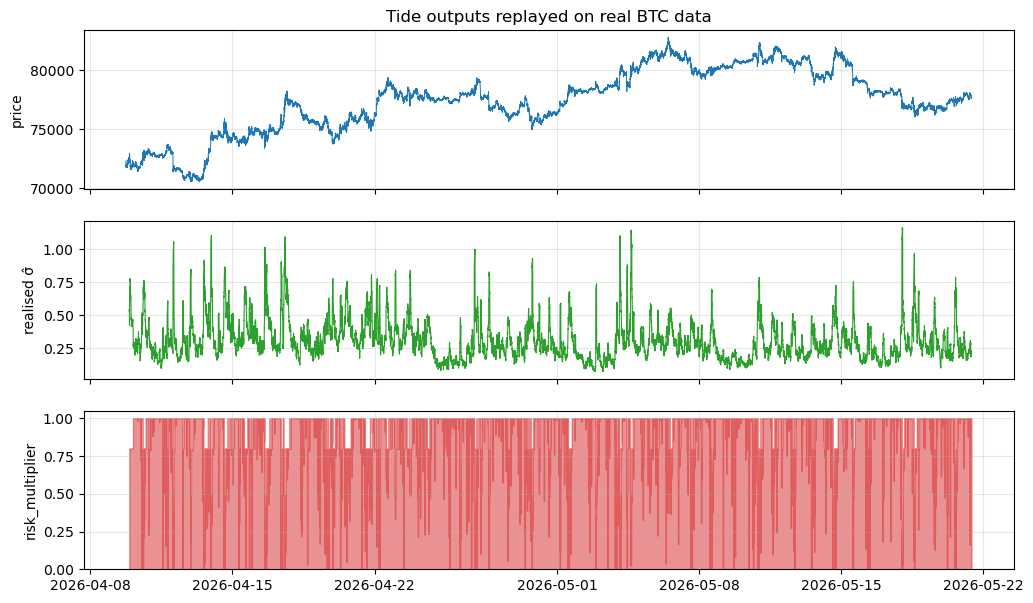

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(ohlcv.index, ohlcv['close'], color='#1f77b4', linewidth=0.7)
axes[0].set_ylabel('price'); axes[0].grid(alpha=0.3)
axes[1].plot(trace.index, trace['vol'], color='#2ca02c', linewidth=0.8)
axes[1].set_ylabel('realised σ̂'); axes[1].grid(alpha=0.3)
axes[2].fill_between(trace.index, trace['rm'], step='pre',
                     color='#d62728', alpha=0.5)
axes[2].set_ylabel('risk_multiplier'); axes[2].set_ylim(0, 1.05)
axes[2].grid(alpha=0.3)
axes[0].set_title('Tide outputs replayed on real BTC data')
plt.show()

## 8. Capital allocation hierarchy (§7.8)
Reminder of the budget cascade that Tide owns:

In [19]:
alloc = pd.DataFrame([
    {'level': 'Global',              'sets': 'config / user', 'constrains': 'total portfolio ES'},
    {'level': 'Strategy sleeve',     'sets': 'Tide',          'constrains': 'ES per strategy'},
    {'level': 'Asset',               'sets': 'Tide',          'constrains': 'ES per asset (all sleeves)'},
    {'level': 'Cell (strategy×asset)', 'sets': 'Tide',        'constrains': 'ES for one cell'},
])
alloc

,level,sets,constrains
0,Global,config / user,total portfolio ES
1,Strategy sleeve,Tide,ES per strategy
2,Asset,Tide,ES per asset (all sleeves)
3,Cell (strategy×asset),Tide,ES for one cell


## Takeaways

* Realised vol on BTC moves between ~0.3 and ~1.5 annualised on
  multi-month windows — `vol_regime` flips correspondingly.
* `risk_multiplier` is piecewise-linear; the LSI penalty kicks in
  *after* the regime base.  This is the single scalar that
  throttles every Ripple position.
* `risk_multiplier == 0` is special: it forces an immediate
  risk-budget exit on *all* open trades (§7.4.7 invariant).